## Targets of this notebook
- find the anomalous behaviour within the dataset
- provide insights on data from ML perspecive (outlier-wise)
- serve as a first step towards anomaly detesction using Deep learning

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from anomaly_detection.utils.plotting_styles import apply_global_style
from anomaly_detection.utils.load_sam_data import load_dataset

# FJ

In [2]:
dataset = load_dataset("FJ")

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch


In [3]:
from anomaly_detection.utils.autoencoders import minmax_scale_per_sample
dataset = minmax_scale_per_sample(dataset)

In [4]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

neigh = NearestNeighbors(n_neighbors=len(dataset))
neigh.fit(dataset)

neighborhood = []
for d in dataset:
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]

mean = np.mean(avg_distances)
deviations = [abs(d-mean) for d in avg_distances]

In [5]:
len(set(deviations))

613

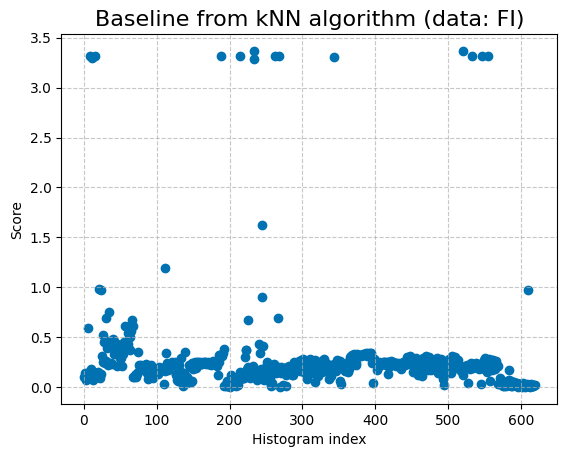

In [6]:
apply_global_style()
plt.title("Baseline from kNN algorithm (data: FI)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(deviations)), deviations)

In [7]:
possible_outlier =  [deviations.index(dev) for dev in deviations if dev > 1.5 and dev < 2]
possible_outlier

[244]

## Points that could be outliers

In [8]:
outliers_knn = np.where(np.array(deviations) > 2.0)[0].tolist()
print(outliers_knn)
len(outliers_knn)

[8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]


14

In [9]:
for i in outliers_knn:
    print(i, deviations[i])

8 3.3129048385862907
11 3.2947734888458013
15 3.3129048385862907
188 3.3129048385862907
214 3.3129048385862907
233 3.286210358328642
234 3.365502678956962
263 3.3129048385862907
268 3.3129048385862907
344 3.310506111376954
520 3.3678831294594804
533 3.3129048385862907
546 3.3129048385862907
555 3.321789143924997


In [10]:
[8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555] == outliers_knn

True

In [11]:
knn_weird = [deviations.index(dev) for dev in deviations if dev > 1]
knn_weird = [i for i in knn_weird if i > 500]
knn_weird

[520, 555]

In [12]:
deviations[555]

np.float64(3.321789143924997)

In [13]:
table = {deviations.index(dev): round(dev, 4) for dev in deviations if dev > 1.5}
table

{8: np.float64(3.3129),
 11: np.float64(3.2948),
 233: np.float64(3.2862),
 234: np.float64(3.3655),
 244: np.float64(1.6264),
 344: np.float64(3.3105),
 520: np.float64(3.3679),
 555: np.float64(3.3218)}

<BarContainer object of 96 artists>

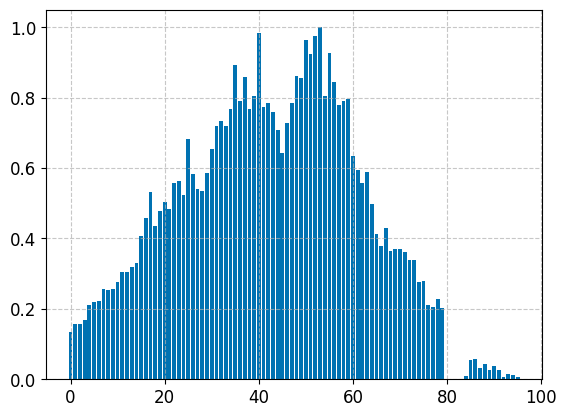

In [14]:
apply_global_style()
plt.bar(range(len(dataset[361])), dataset[361])

## Is point 113 outlier?

<BarContainer object of 96 artists>

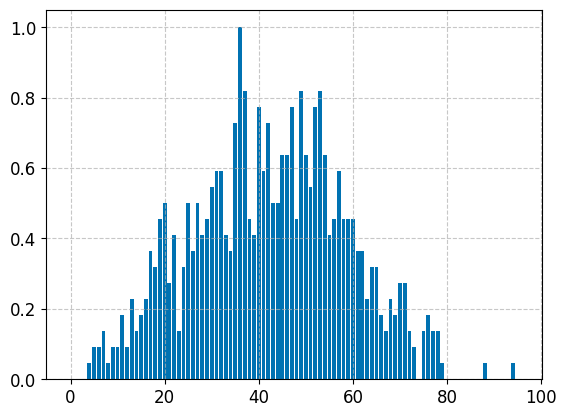

In [15]:
apply_global_style()

plt.bar(range(len(dataset[613])), dataset[113])

## Let's try OCSVM

In [16]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf').fit(dataset)
svm.fit_predict(dataset)
prediction = svm.predict(dataset)
out_measure = svm.score_samples(dataset)

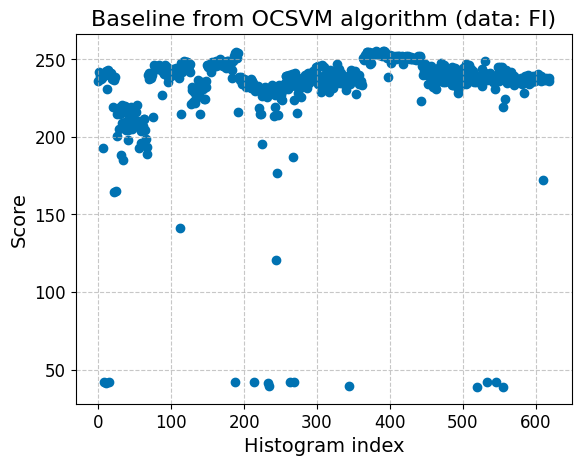

In [17]:
apply_global_style()
plt.title("Baseline from OCSVM algorithm (data: FI)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(out_measure)), out_measure)

In [18]:
len(outliers_knn)

14

In [20]:
outliers_svm = np.where(out_measure < 50)
outliers_svm = outliers_svm[0]

print("(SVM) Highest outlier score assigned to: ", np.where(out_measure == min(out_measure))[0].tolist())
print("(KNN) Highest outlier score assigned to: ", deviations.index(max(deviations)))
print(outliers_svm.tolist() == outliers_knn)
print(f"Outliers detected by svm {outliers_svm.tolist()}")
print(f"Outliers detected by knn {outliers_knn}")
print(f'Same number of outliers: {len(outliers_knn) == len(outliers_svm)}')

(SVM) Highest outlier score assigned to:  [520]
(KNN) Highest outlier score assigned to:  520
True
Outliers detected by svm [8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]
Outliers detected by knn [8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]
Same number of outliers: True


In [21]:
sorted(out_measure[-10:])

[np.float64(172.20706424725495),
 np.float64(235.93636853935007),
 np.float64(236.53717031232426),
 np.float64(236.99681724880054),
 np.float64(237.22801480158643),
 np.float64(237.24514116221613),
 np.float64(237.3665288265288),
 np.float64(237.6634894658379),
 np.float64(237.80032606669835),
 np.float64(238.10602532237587)]

In [22]:
table_svm = {idx : round(score, 4) for idx, score in enumerate(out_measure) if score < 50}
table_svm

{8: np.float64(41.6512),
 11: np.float64(41.1477),
 15: np.float64(41.6512),
 188: np.float64(41.6512),
 214: np.float64(41.6512),
 233: np.float64(41.4012),
 234: np.float64(39.1337),
 263: np.float64(41.6512),
 268: np.float64(41.6512),
 344: np.float64(39.6349),
 520: np.float64(38.777),
 533: np.float64(41.6512),
 546: np.float64(41.6512),
 555: np.float64(38.9137)}

In [23]:
len(table_svm)

14

In [24]:
np.where(np.array(deviations) > 3)

(array([  8,  11,  15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546,
        555]),)

In [25]:
sorted(deviations)[-14:]

[np.float64(3.286210358328642),
 np.float64(3.2947734888458013),
 np.float64(3.310506111376954),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.321789143924997),
 np.float64(3.365502678956962),
 np.float64(3.3678831294594804)]

In [26]:
len(deviations)

620

In [27]:
table_knn = [(deviations.index(dev), round(dev, 4)) for dev in deviations if dev > 3]
table_knn

[(8, np.float64(3.3129)),
 (11, np.float64(3.2948)),
 (8, np.float64(3.3129)),
 (8, np.float64(3.3129)),
 (8, np.float64(3.3129)),
 (233, np.float64(3.2862)),
 (234, np.float64(3.3655)),
 (8, np.float64(3.3129)),
 (8, np.float64(3.3129)),
 (344, np.float64(3.3105)),
 (520, np.float64(3.3679)),
 (8, np.float64(3.3129)),
 (8, np.float64(3.3129)),
 (555, np.float64(3.3218))]

In [28]:
table_knn = {deviations.index(dev): round(dev, 4) for dev in deviations if dev > 3}
table_knn

{8: np.float64(3.3129),
 11: np.float64(3.2948),
 233: np.float64(3.2862),
 234: np.float64(3.3655),
 344: np.float64(3.3105),
 520: np.float64(3.3679),
 555: np.float64(3.3218)}

In [29]:
table_knn = {deviations.index(dev): round(dev, 4) for dev in deviations if dev > 3}
table_knn

{8: np.float64(3.3129),
 11: np.float64(3.2948),
 233: np.float64(3.2862),
 234: np.float64(3.3655),
 344: np.float64(3.3105),
 520: np.float64(3.3679),
 555: np.float64(3.3218)}

In [30]:
len(table_knn)

7

# PA

In [31]:
pa_data = load_dataset("PA")

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\MWPC\PA01U1\PA01U1_ch


<BarContainer object of 768 artists>

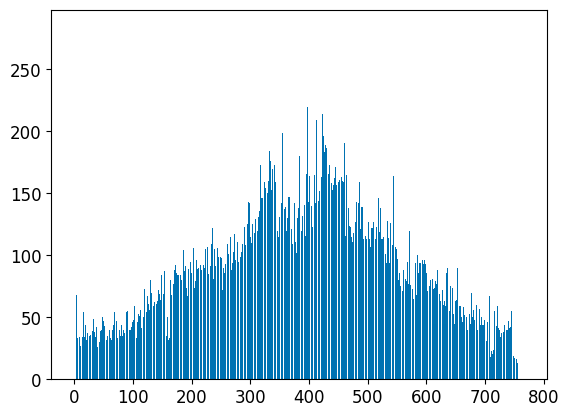

In [32]:
plt.bar(range(len(pa_data[0])), pa_data[0])

In [34]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()
#pa_data = scaler.fit_transform(pa_data)

pa_data = minmax_scale_per_sample(pa_data)

neigh = NearestNeighbors(n_neighbors=len(pa_data))
neigh.fit(pa_data)

neighborhood = []
for d in pa_data:
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]

mean = np.mean(avg_distances)
deviations = [abs(d-mean) for d in avg_distances]

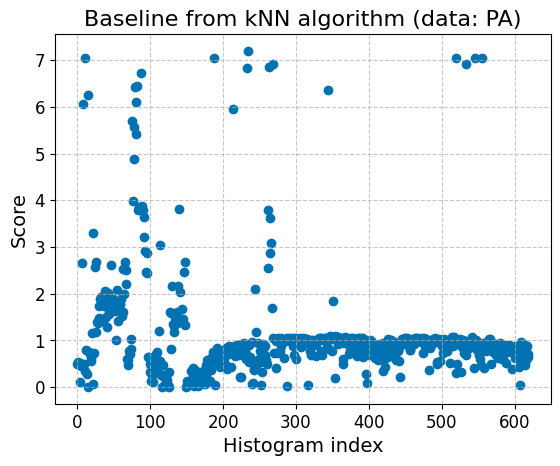

In [35]:
apply_global_style()
plt.title("Baseline from kNN algorithm (data: PA)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(deviations)), deviations)

In [36]:
outliers_knn = [deviations.index(dev) for dev in deviations if dev > 6]
len(outliers_knn), outliers_knn

(17,
 [8, 11, 15, 79, 81, 82, 87, 11, 233, 234, 263, 268, 344, 520, 533, 11, 555])

In [37]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf').fit(pa_data)
svm.fit_predict(pa_data)
prediction = svm.predict(pa_data)
out_measure = svm.score_samples(pa_data)

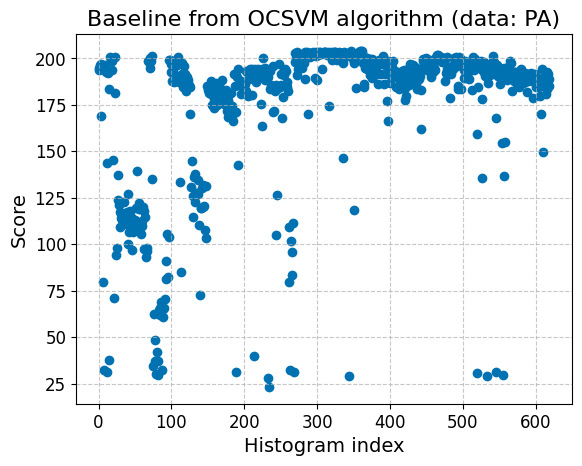

In [38]:
apply_global_style()
plt.title("Baseline from OCSVM algorithm (data: PA)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(out_measure)), out_measure)

In [39]:
outliers_svm = np.where(out_measure < 50)
outliers_svm = outliers_svm[0]

print("(SVM) Highest outlier score assigned to: ", np.where(out_measure == min(out_measure))[0].tolist())
print("(KNN) Highest outlier score assigned to: ", deviations.index(max(deviations)))
print(outliers_svm.tolist() == outliers_knn)
print(f"Outliers detected by svm {outliers_svm.tolist()}")
print(f"Outliers detected by knn {outliers_knn}")

(SVM) Highest outlier score assigned to:  [234]
(KNN) Highest outlier score assigned to:  234
False
Outliers detected by svm [8, 11, 15, 75, 77, 78, 79, 80, 81, 82, 87, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]
Outliers detected by knn [8, 11, 15, 79, 81, 82, 87, 11, 233, 234, 263, 268, 344, 520, 533, 11, 555]


Zde vidime ze pokud vezmeme hranici 60 ktera se zda byt vhodna dostavame v SVM pristupu o jeden outlier vice dataset je mnohem vice scattered a narozdil od predesleho FJ datasetu je v nem mnohem vic nejasnych bodu, ikdyz se na prvni pohled metody shodujji v skorovani vidime ze OCSVM je dulezite na zaklade tehto vysledku byt ostrazity hlavne v dobech ktere se nachazi mezi jasnymi outliery a clustrem bodu ktere jsou blizko u sebe.. (neco takoveho napsat idk)

# SI

In [40]:
si_data = load_dataset("SI")

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\SI\SI01U1\SI01U1_ch


<BarContainer object of 1280 artists>

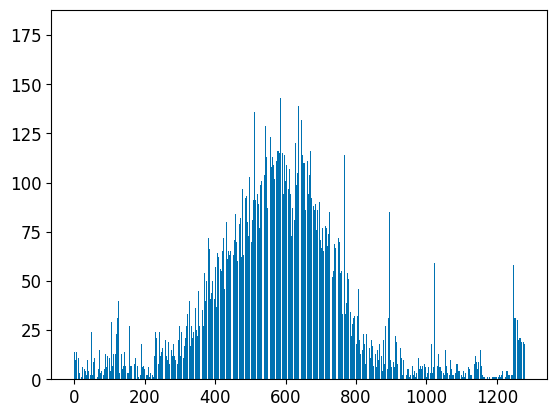

In [41]:
plt.bar(range(len(si_data[0])), si_data[0])

In [43]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()
#si_data = scaler.fit_transform(si_data)

si_data = minmax_scale_per_sample(si_data)

neigh = NearestNeighbors(n_neighbors=len(si_data))
neigh.fit(si_data)

neighborhood = []
for d in si_data:
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]

mean = np.mean(avg_distances)
deviations = [abs(d-mean) for d in avg_distances]

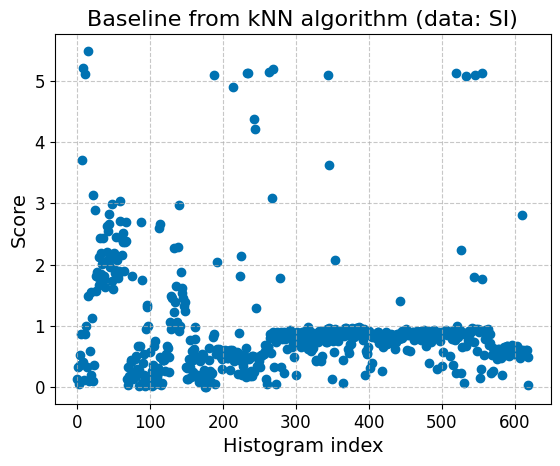

In [44]:
apply_global_style()
plt.title("Baseline from kNN algorithm (data: SI)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(deviations)), deviations)

In [50]:
np.where(np.array(deviations) > 2)

(array([  6,   8,  11,  15,  21,  24,  29,  31,  33,  34,  35,  39,  40,
         41,  42,  43,  44,  46,  48,  50,  53,  54,  58,  59,  60,  61,
         62,  63,  65,  66,  67,  87, 112, 113, 133, 138, 139, 188, 192,
        214, 225, 233, 234, 243, 244, 263, 267, 268, 344, 345, 353, 520,
        527, 533, 546, 555, 610]),)

<BarContainer object of 1280 artists>

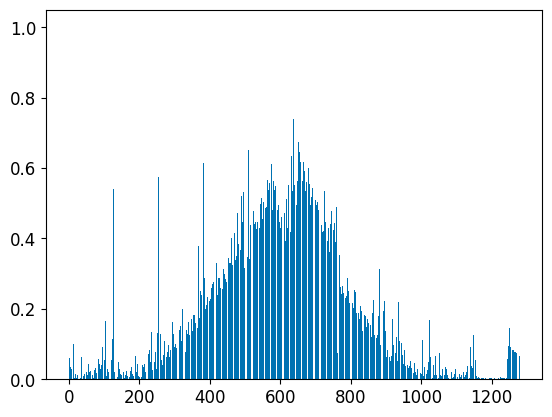

In [46]:
plt.bar(range(len(si_data[347])), si_data[347])

In [47]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf').fit(si_data)
svm.fit_predict(si_data)
prediction = svm.predict(si_data)
out_measure = svm.score_samples(si_data)

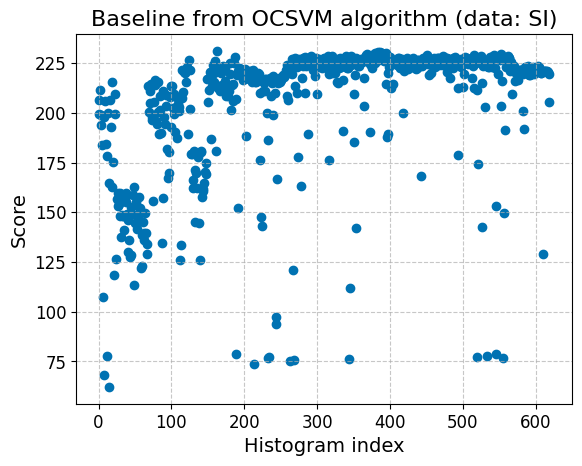

In [48]:
apply_global_style()
plt.title("Baseline from OCSVM algorithm (data: SI)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(out_measure)), out_measure)

In [49]:
outliers_svm = np.where(out_measure < 60)
outliers_svm = outliers_svm[0]

print("(SVM) Highest outlier score assigned to: ", np.where(out_measure == min(out_measure))[0].tolist())
print("(KNN) Highest outlier score assigned to: ", deviations.index(max(deviations)))
print(outliers_svm.tolist() == outliers_knn)
print(f"Outliers detected by svm {outliers_svm}")
print(f"Outliers detected by knn {outliers_knn}")

(SVM) Highest outlier score assigned to:  [15]
(KNN) Highest outlier score assigned to:  15
False
Outliers detected by svm []
Outliers detected by knn [8, 11, 15, 79, 81, 82, 87, 11, 233, 234, 263, 268, 344, 520, 533, 11, 555]
